In [1]:
from itertools import product
import numpy as np
from tqdm import tqdm

from premise.models import default_models
from premise.system import ACASSystemUnderObservation, MCSystemUnderObservation

horizons = np.arange(1, 3 + 1, 1, dtype=int)
initial_amounts = np.arange(1, 50 + 1, 5, dtype=int)


suos: dict[tuple[int, int], MCSystemUnderObservation] = {}
for h, i in tqdm(
    product(horizons, initial_amounts), total=len(horizons) * len(initial_amounts)
):
    print(f"Creating system for horizon {h} and initial amount {i}")
    model_def = default_models["unlikely-20"]
    # model_def.constants = "DMAX=4,PMAX=4"
    model_def.risk_property = f'Pmax=? [ F<={h} "{model_def.target_label}" ]'
    suo = MCSystemUnderObservation(model_def, "")

    suos[(h, i)] = suo

 60%|██████    | 18/30 [00:00<00:00, 86.17it/s]

Creating system for horizon 1 and initial amount 1
ERROR (ExpressionManager.cpp:232): Unknown variable 'crash'.
Creating system for horizon 1 and initial amount 6
Creating system for horizon 1 and initial amount 11
ERROR (ExpressionManager.cpp:232): Unknown variable 'depth'.
ERROR (ExpressionManager.cpp:232): Unknown variable 'game_started'.
Creating system for horizon 1 and initial amount 16
Creating system for horizon 1 and initial amount 21
ERROR (ExpressionManager.cpp:232): Unknown variable 'crash'.
ERROR (ExpressionManager.cpp:232): Unknown variable 'depth'.
ERROR (ExpressionManager.cpp:232): Unknown variable 'game_started'.
ERROR (ExpressionManager.cpp:232): Unknown variable 'crash'.
ERROR (ExpressionManager.cpp:232): Unknown variable 'depth'.
ERROR (ExpressionManager.cpp:232): Unknown variable 'game_started'.
ERROR (ExpressionManager.cpp:232): Unknown variable 'crash'.
ERROR (ExpressionManager.cpp:232): Unknown variable 'depth'.
ERROR (ExpressionManager.cpp:232): Unknown variabl

100%|██████████| 30/30 [00:00<00:00, 80.61it/s]

Creating system for horizon 3 and initial amount 26
ERROR (ExpressionManager.cpp:232): Unknown variable 'crash'.
Creating system for horizon 3 and initial amount 31
Creating system for horizon 3 and initial amount 36
ERROR (ExpressionManager.cpp:232): Unknown variable 'depth'.
ERROR (ExpressionManager.cpp:232): Unknown variable 'game_started'.
ERROR (ExpressionManager.cpp:232): Unknown variable 'crash'.
ERROR (ExpressionManager.cpp:232): Unknown variable 'depth'.
ERROR (ExpressionManager.cpp:232): Unknown variable 'game_started'.
ERROR (ExpressionManager.cpp:232): Unknown variable 'crash'.
ERROR (ExpressionManager.cpp:232): Unknown variable 'depth'.
ERROR (ExpressionManager.cpp:232): Unknown variable 'game_started'.
ERROR (ExpressionManager.cpp:232): Unknown variable 'crash'.
ERROR (ExpressionManager.cpp:232): Unknown variable 'depth'.
ERROR (ExpressionManager.cpp:232): Unknown variable 'game_started'.
ERROR (ExpressionManager.cpp:232): Unknown variable 'crash'.
ERROR (ExpressionManage

In [2]:
test_amount = 10000

suo_stats = {}
samples = []
for i in tqdm(list(range(test_amount))):
    samples += suos[(horizons[0], initial_amounts[0])].generate_random_traces(
        [], max(horizons) + max(initial_amounts)
    )

for (h, i), suo in tqdm(suos.items()):
    crashed_before_horizon = 0
    crashed_in_horizon = 0
    no_crashed = 0
    for sample in samples:
        if any(s[2] for s in sample[:i]):
            crashed_before_horizon += 1
        elif any(s[2] for s in sample[i : i + h]):
            crashed_in_horizon += 1
        else:
            no_crashed += 1
    suo_stats[(h, i)] = {
        "crashed_before_horizon": crashed_before_horizon,
        "crashed_in_horizon": crashed_in_horizon,
        "no_crashed": no_crashed,
    }

sample_crash_states = []
suo = suos[(horizons[0], initial_amounts[0])]
for sample in samples:
    for i, s in enumerate(sample):
        if s[2]:
            sample_crash_states.append(i)
            break
    else:
        sample_crash_states.append(len(sample))  # infinity

100%|██████████| 30/30 [00:00<00:00, 75.65it/s]


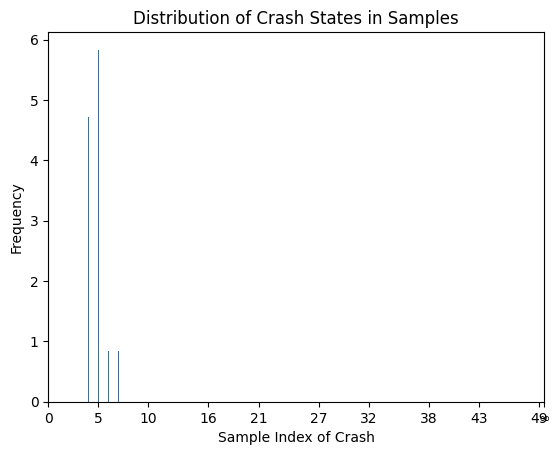

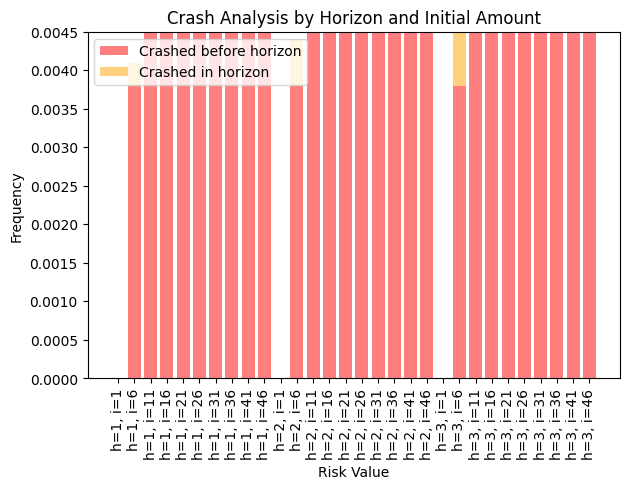

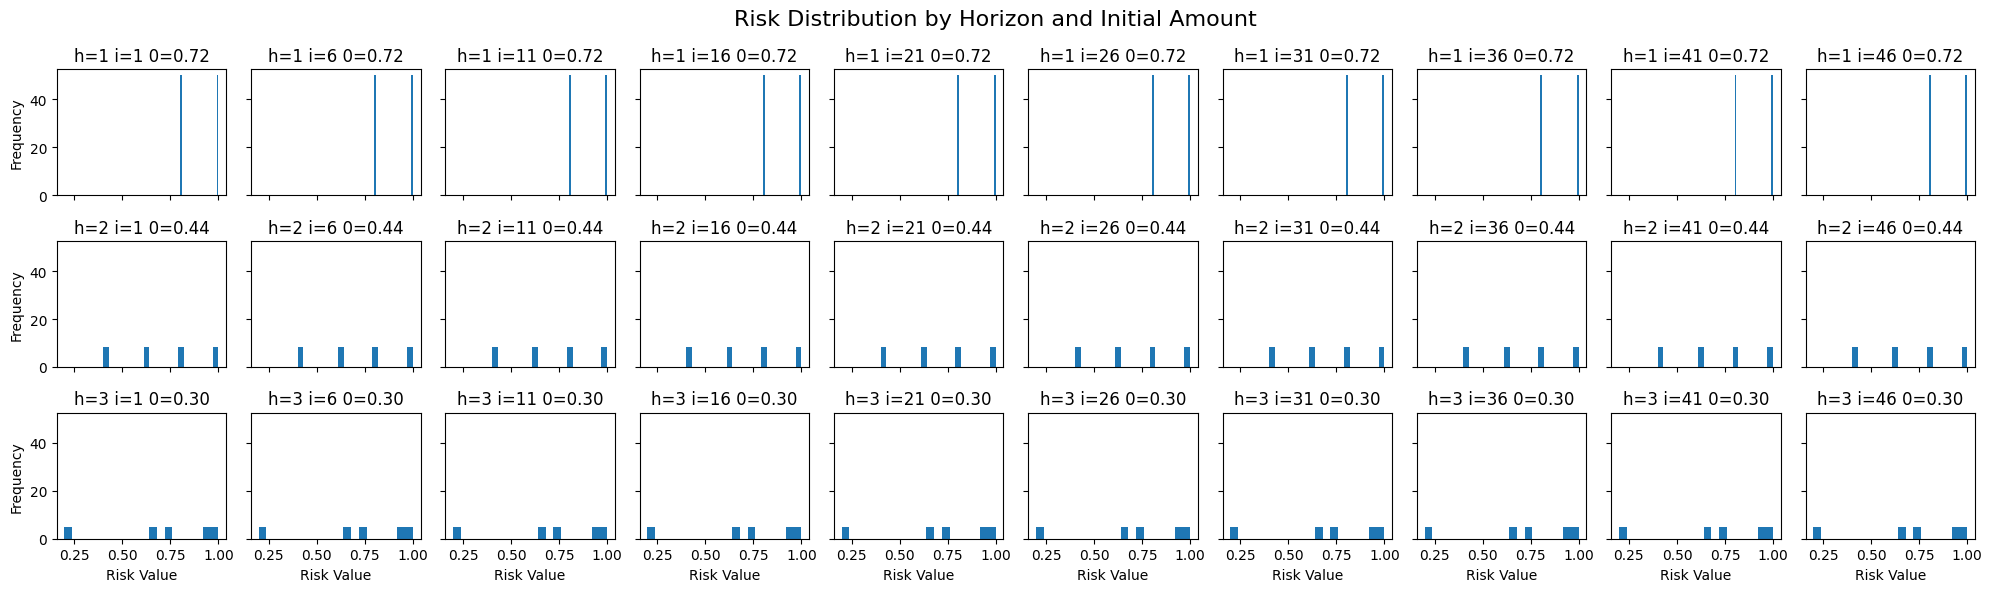

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
sample_crash_states_without_infinity = [
    s for s in sample_crash_states if s < max(horizons) + max(initial_amounts)
]
ax.hist(
    sample_crash_states_without_infinity,
    density=True,
    bins=max(horizons) + max(initial_amounts) + 1,
)
ax.set_xlabel("Sample Index of Crash")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Crash States in Samples")
ax.set_xticks(
    np.linspace(0, max(horizons) + max(initial_amounts), num=10, dtype=int).tolist()
    + [max(horizons) + max(initial_amounts) + 0.5]
)
ax.set_xticklabels(
    np.linspace(0, max(horizons) + max(initial_amounts), num=10, dtype=int).tolist()
    + ["∞"]
)


fig, ax = plt.subplots()
for (h, i), stats in suo_stats.items():
    ax.bar(
        f"h={h}, i={i}",
        stats["crashed_before_horizon"] / test_amount,
        label="Crashed before horizon",
        color="red",
        alpha=0.5,
    )
    ax.bar(
        f"h={h}, i={i}",
        stats["crashed_in_horizon"] / test_amount,
        bottom=stats["crashed_before_horizon"] / test_amount,
        label="Crashed in horizon",
        color="orange",
        alpha=0.5,
    )
    # ax.bar(
    #     f"h={h}, i={i}",
    #     stats["no_crashed"] / test_amount,
    #     bottom=stats["crashed_before_horizon"] / test_amount
    #     + stats["crashed_in_horizon"] / test_amount,
    #     label="No crash",
    #     color="green",
    #     alpha=0.5,
    # )
ax.set_ylabel("Number of samples")
ax.set_title("Crash Analysis by Horizon and Initial Amount")
plt.xticks(rotation=90)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="upper left")
plt.tight_layout()
# ax.set_ylim(0, 1)

# Create a grid of subplots for all (h, i) combinations
n_h = len(horizons)
n_i = len(initial_amounts)
fig_hist, axes = plt.subplots(
    n_h, n_i, figsize=(2 * n_i, 2 * n_h), sharex=True, sharey=True
)

zero_threshold = 0.001
for row, h in enumerate(horizons):
    for col, i in enumerate(initial_amounts):
        ax_hist = axes[row, col]
        suo = suos[(h, i)]
        val = [float(r) for r in suo.risk if float(r) > zero_threshold]
        ax_hist.hist(
            val,
            bins=20,
            alpha=1,
            density=True,
        )
        ax_hist.set_title(
            f"h={h} i={i} 0={(len(suo.risk) - len(val))/len(suo.risk):.2f}"
        )
        if row == n_h - 1:
            ax_hist.set_xlabel("Risk Value")
        if col == 0:
            ax_hist.set_ylabel("Frequency")

fig_hist.suptitle("Risk Distribution by Horizon and Initial Amount", fontsize=16)
ax.set_xlabel("Risk Value")
ax.set_ylabel("Frequency")
# ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()